In [1]:
!pip install kagglehub
import kagglehub


path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print(path)

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
/kaggle/input/students-performance-in-exams


In [2]:
import os
print(os.listdir(path))

['StudentsPerformance.csv']


In [3]:
import pandas as pd
import os

file = os.path.join(path, "StudentsPerformance.csv")

df = pd.read_csv(file)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Rows and Columns: (1000, 8)

Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

(1000, 8)

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows:
0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [13]:
df_encoded['average_score'] = (
    df_encoded['math score'] +
    df_encoded['reading score'] +
    df_encoded['writing score']
) / 3

df_encoded['performance'] = df_encoded['average_score'].apply(
    lambda x: 1 if x >= 60 else 0
)

df_encoded.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


In [14]:
X = df_encoded.drop(['average_score', 'performance'], axis=1)
y = df_encoded['performance']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 0 1 0]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.98


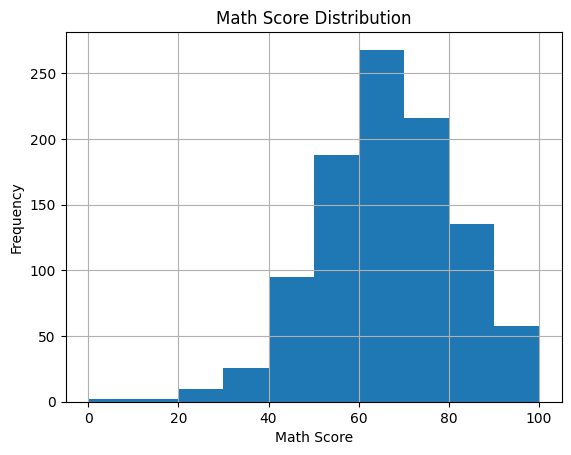

In [19]:
import matplotlib.pyplot as plt

df['math score'].hist()

plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

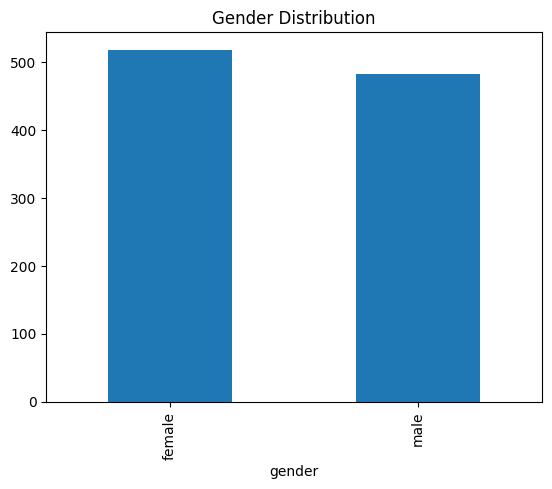

In [20]:
df['gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.show()

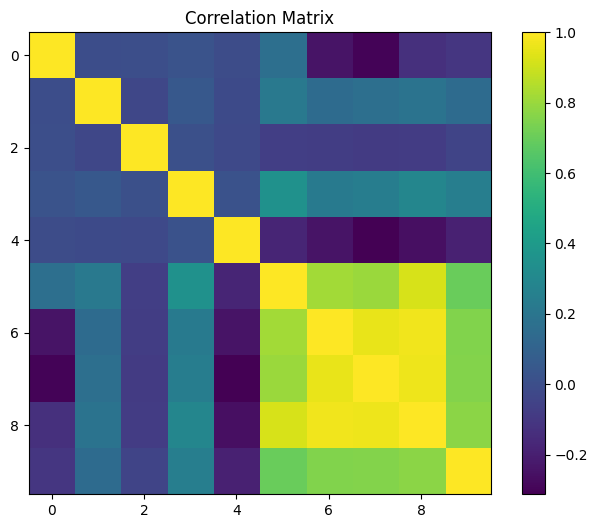

In [21]:
import matplotlib.pyplot as plt

corr = df_encoded.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 61   1]
 [  3 135]]


In [23]:
def get_recommendation(math, reading, writing):

    avg = (math + reading + writing) / 3

    if avg >= 80:
        return "Excellent performance. Maintain your current study habits."

    elif avg >= 60:
        return "Good performance. Focus on improving weaker subjects."

    else:
        return "Performance needs improvement. Increase study hours, complete test preparation courses, and practice daily."

In [24]:
print(get_recommendation(45, 50, 55))

Performance needs improvement. Increase study hours, complete test preparation courses, and practice daily.


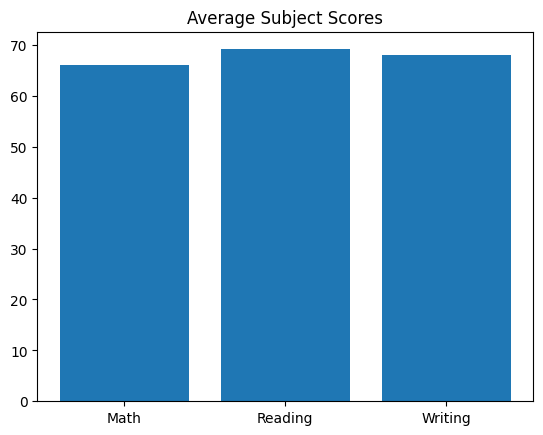

In [25]:
scores = [
    df['math score'].mean(),
    df['reading score'].mean(),
    df['writing score'].mean()
]

subjects = ['Math', 'Reading', 'Writing']

plt.bar(subjects, scores)
plt.title('Average Subject Scores')
plt.show()

In [31]:
!pip install streamlit pyngrok -q

In [32]:
%%writefile app.py

import streamlit as st

st.set_page_config(page_title="Student Performance Prediction", layout="wide")

st.title("🎓 Student Performance Prediction System")

col1, col2 = st.columns(2)

with col1:
    st.metric("Model Accuracy", "98%")

with col2:
    st.metric("Algorithm", "Random Forest")

st.subheader("Student Score Input")

math_score = st.slider("Math Score", 0, 100, 50)
reading_score = st.slider("Reading Score", 0, 100, 50)
writing_score = st.slider("Writing Score", 0, 100, 50)

if st.button("Predict"):

    avg = (math_score + reading_score + writing_score) / 3

    if avg >= 60:
        prediction = "Good Performance"
        recommendation = "Continue your current study habits and practice advanced problems."
    else:
        prediction = "Needs Improvement"
        recommendation = "Increase study hours and focus on weak subjects."

    st.success(f"Prediction: {prediction}")

    st.subheader("🤖 GPT Recommendation")
    st.info(recommendation)

Overwriting app.py


In [33]:
!streamlit run app.py &>/content/logs.txt &

In [34]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-06-16T11:31:51+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-16T11:31:51+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-16T11:31:51+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [35]:
!ngrok config add-authtoken 3FDVU38qn7BUkkZzuukiMPsEvf6_7fLQGfnAWLJ8bs5kKsbm9

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [36]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://wobbling-epiphany-bonsai.ngrok-free.dev" -> "http://localhost:8501"
